In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trash_df = pd.read_csv('../data/trash_hauler_report.csv')
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011


In [3]:
trash_df.shape

(20226, 11)

In [4]:
trash_df['Request '].value_counts()

Request 
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [5]:
trash_df = trash_df.rename(columns = {'Request ': 'Request'})
trash_df.columns

Index(['Request Number', 'Date Opened', 'Request', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y'],
      dtype='object')

In [6]:
trash_df['Request'].value_counts()

Request
Trash - Curbside/Alley Missed Pickup    15028
Trash - Backdoor                         2629
Trash Collection Complaint               2312
Damage to Property                        257
Name: count, dtype: int64

In [7]:
request_count = trash_df['Request'].value_counts()
request_count = request_count.reset_index()
request_count

,Request,count
0,Trash - Curbside/Alley Missed Pickup,15028
1,Trash - Backdoor,2629
2,Trash Collection Complaint,2312
3,Damage to Property,257


In [8]:
trash_df['Zip Code'].dtype

dtype('float64')

In [9]:
trash_df['Zip Code'].astype(float).astype(str).str.replace('.0','')

0        37207
1        37218
2        37209
3        37207
4        37209
         ...  
20221    37013
20222    37206
20223    37214
20224    37013
20225    37217
Name: Zip Code, Length: 20226, dtype: object

In [10]:
trash_df['Zip Code'] = trash_df['Zip Code'].astype(float).astype(str).str.replace('.0','')
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011


In [11]:
trash_df['Zip Code'].value_counts().head()

Zip Code
37013    2278
37211    2248
37205    1491
37209    1411
37215    1404
Name: count, dtype: int64

In [12]:
zip_count = trash_df['Zip Code'].value_counts()
zip_count = zip_count.reset_index()
zip_count.head()

,Zip Code,count
0,37013,2278
1,37211,2248
2,37205,1491
3,37209,1411
4,37215,1404


In [13]:
trash_df['Incident Address'] = trash_df['Incident Address'].str.title()
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011


In [14]:
trash_df['Address2'] = trash_df['Incident Address'].str.split(',', expand = True)[0]

In [15]:
trash_df['City'] = trash_df['Incident Address'].str.split(',', expand = True)[1]
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address2,City
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None


In [16]:
address_count = trash_df['Incident Address'].value_counts()
address_count = address_count.reset_index()
address_count.head()

,Incident Address,count
0,3710 N Natchez Ct,21
1,5135 Hickory Hollow Pkwy,21
2,"6007 Obrien Ave, Nashville, Tn 37209, United S...",19
3,"12546 Old Hickory Blvd, Nashville, Tn 37013, U...",19
4,"802 Crescent Rd, Nashville, Tn 37205, United S...",18


In [17]:
address2_count = trash_df['Address2'].value_counts()
address2_count = address2_count.reset_index()
address2_count.head()

,Address2,count
0,110 George L Davis Blvd,29
1,5135 Hickory Hollow Pkwy,23
2,3710 N Natchez Ct,22
3,12546 Old Hickory Blvd,21
4,6007 Obrien Ave,20


In [18]:
#this didnt work
missed_text = ['missed', 'miss', 'skip', 'skipped', 'not picked', 'failed', 'fail', 'forgot']

In [19]:
trash_df['Missed Trash'] = trash_df['Description'].str.contains('missed|miss|skip|skipped|not picked|failed|fail|forgot|never|did not', case=False, na=False)
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address2,City,Missed Trash
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None,False
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None,True
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None,True
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None,True
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None,True


In [20]:
trash_df['Missed2'] = (trash_df['Description'].str.contains('missed|miss|skip|skipped|not picked|failed|fail|forgot|never|did not', case=False, na=False)
    | (trash_df['Request'] == 'Trash - Curbside/Alley Missed Pickup'))
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address2,City,Missed Trash,Missed2
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None,False,False
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None,True,True
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None,True,True
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None,True,True
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None,True,True


In [21]:
# miss matched 'Missed' columns
(trash_df['Missed Trash'] != trash_df['Missed2']).sum()

np.int64(3483)

In [ ]:
trash_df['Year'] = trash_df[

In [22]:
trash_df['Missed Trash'].value_counts()

Missed Trash
True     14547
False     5679
Name: count, dtype: int64

In [23]:
trash_df['Trash Hauler'] = trash_df['Trash Hauler'].replace('Metro', 'METRO')

In [24]:
hauler_count = trash_df['Missed2'].groupby(trash_df['Trash Hauler']).value_counts()
hauler_count = hauler_count.reset_index()
hauler_count.head()

,Trash Hauler,Missed2,count
0,METRO,True,3085
1,METRO,False,495
2,RED RIVER,True,13025
3,RED RIVER,False,1370
4,WASTE IND,True,1152


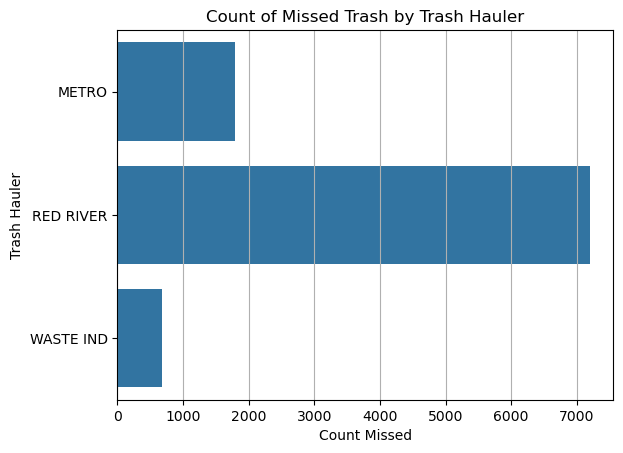

<function seaborn.categorical.barplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, hue_norm=None, width=0.8, dodge='auto', gap=0, log_scale=None, native_scale=False, formatter=None, legend='auto', capsize=0, err_kws=None, ci=<deprecated>, errcolor=<deprecated>, errwidth=<deprecated>, ax=None, **kwargs)>

In [63]:
count_missed_bar = sns.barplot(data = hauler_count, x = 'count', y = 'Trash Hauler', errorbar = None);
count_missed_bar.set_title('Count of Missed Trash by Trash Hauler')
count_missed_bar.set_xlabel('Count Missed')
count_missed_bar.set_ylabel('Trash Hauler')
count_missed_bar.grid(axis='x')
#count_missed_bar.set_xticks(range(0, 1000000, 100000))
plt.savefig('amount_owed_by_hauler.png', dpi=300, bbox_inches='tight')
plt.show()
sns.barplot

In [26]:
trash_df['Address3'] = trash_df['Address2'] + ' ' + trash_df['Zip Code']
trash_df.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Address2,City,Missed Trash,Missed2,Address3
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2.0,1727970.412,686779.4781,3817 Crouch Dr,None,False,False,3817 Crouch Dr 37207
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1.0,1721259.366,685444.7996,4028 Clarksville Pike,None,True,True,4028 Clarksville Pike 37218
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20.0,1707026.753,659887.4716,6528 Thunderbird Dr,None,True,True,6528 Thunderbird Dr 37209
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 Old Matthews Rd,37207,WASTE IND,2206,2.0,1735691.771,685027.2459,2603 Old Matthews Rd,None,True,True,2603 Old Matthews Rd 37207
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 Croley Dr,37209,RED RIVER,4203,20.0,1710185.772,664205.1011,604 Croley Dr,None,True,True,604 Croley Dr 37209


In [27]:
# do not use, count based on original Missed Trash filter approach
trash_df.loc[trash_df['Missed Trash'] == True].groupby(trash_df['Trash Hauler'])['Address3'].count()

Trash Hauler
METRO         2416
RED RIVER    10639
WASTE IND      886
Name: Address3, dtype: int64

In [28]:
trash_df.loc[trash_df['Missed2'] == True].groupby(trash_df['Trash Hauler'])['Address3'].count()

Trash Hauler
METRO         3084
RED RIVER    13024
WASTE IND     1152
Name: Address3, dtype: int64

In [29]:
trash_df.loc[trash_df['Missed2'] == True].groupby('Trash Hauler')['Address3'].count()

Trash Hauler
METRO         3084
RED RIVER    13024
WASTE IND     1152
Name: Address3, dtype: int64

In [49]:
route_count = (trash_df.loc[trash_df["Missed2"] == True].groupby("Trash Route")["Address3"].count().reset_index(name="route_count"))
route_count = route_count.sort_values("route_count", ascending=False)
route_count.head()

,Trash Route,route_count
133,4504,334
74,3302,295
124,4404,261
150,9303,251
9,1303,251


<Axes: xlabel='Trash Route', ylabel='route_count'>

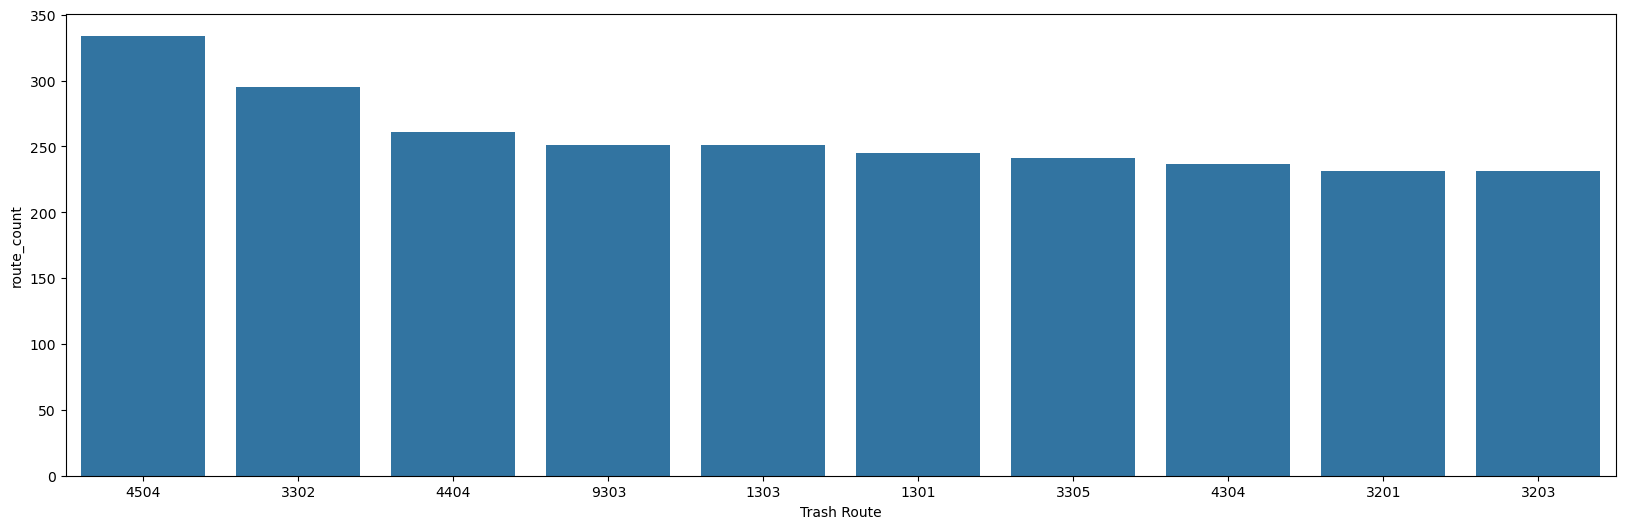

In [60]:
top_10_routes = route_count.nlargest(10, "route_count")
plt.figure(figsize=(20, 6))
sns.barplot(data=top_10_routes, x="Trash Route", y="route_count", errorbar=None)


In [30]:
address3_count = trash_df['Address3'].value_counts()
address3_count = address3_count.reset_index()
address3_count.head()

,Address3,count
0,110 George L Davis Blvd 37203,28
1,5135 Hickory Hollow Pkwy 37013,23
2,3710 N Natchez Ct 37211,22
3,12546 Old Hickory Blvd 37013,21
4,6007 Obrien Ave 37209,20


<Axes: xlabel='count', ylabel='Address3'>

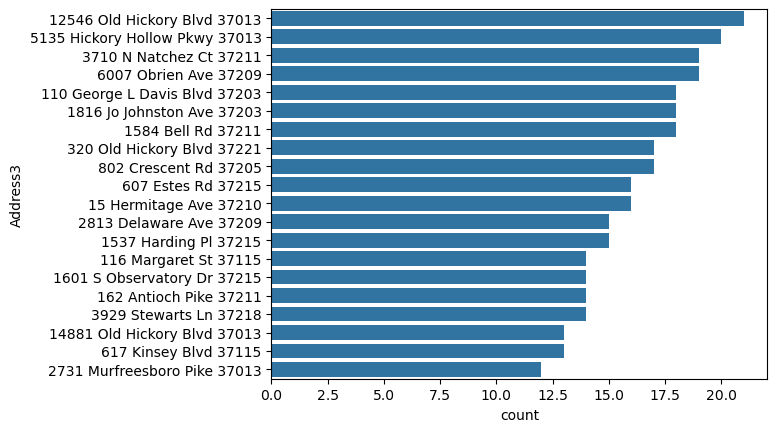

In [44]:
top_20_addresses = address3_count.nlargest(20, "count")

sns.barplot(data=top_20_addresses, x="count", y="Address3", errorbar=None)

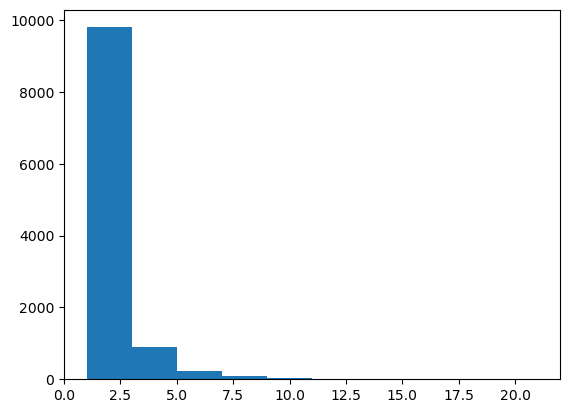

In [42]:
plt.hist(address3_count['count'], bins=10);

In [32]:
address3_count = (trash_df[trash_df['Missed2']].groupby(['Trash Hauler', 'Address3']).size().reset_index(name='count'))
address3_count['missed_pickups'] = address3_count['count'] - 1
address3_count['ammount_owed'] = address3_count['missed_pickups'] * 200
address3_count

,Trash Hauler,Address3,count,missed_pickups,ammount_owed
0,METRO,1 Belle Forrest Ave C 37206,1,0,0
1,METRO,10 Belle Forrest Ave 37206,1,0,0
2,METRO,100 Marshall Ct 37212,2,1,200
3,METRO,1000 Gilmore Ave 37204,1,0,0
4,METRO,1000 N 7Th St 37207,1,0,0
...,...,...,...,...,...
11081,WASTE IND,944 4Th Ave S 37210,2,1,200
11082,WASTE IND,945 31St Ave N 37209,1,0,0
11083,WASTE IND,945 4Th Ave S 37210,2,1,200
11084,WASTE IND,951 Sharpe Ave 37206,1,0,0


In [33]:
missed_by_hauler = address3_count['ammount_owed'].groupby(address3_count['Trash Hauler']).sum()
missed_by_hauler = missed_by_hauler.reset_index()
missed_by_hauler.head()

,Trash Hauler,ammount_owed
0,METRO,222000
1,RED RIVER,934800
2,WASTE IND,78000


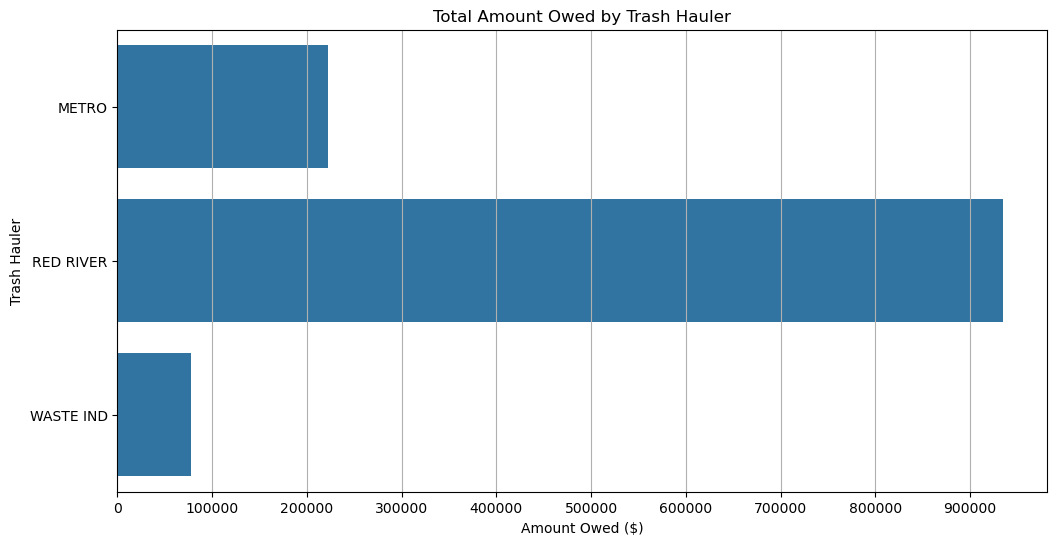

In [61]:
plt.figure(figsize=(12, 6))

amount_owed_bar = sns.barplot(data = missed_by_hauler, x = 'ammount_owed', y = 'Trash Hauler', errorbar = None);
amount_owed_bar.set_title('Total Amount Owed by Trash Hauler')
amount_owed_bar.set_xlabel('Amount Owed ($)')
amount_owed_bar.set_ylabel('Trash Hauler')
amount_owed_bar.grid(axis='x')
amount_owed_bar.set_xticks(range(0, 1000000, 100000))
plt.savefig('amount_owed_by_hauler.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
missed_count_hauler = (address3_count.groupby('Trash Hauler')['missed_pickups'].sum().reset_index(name='total_missed_pickups'))
missed_count_hauler

,Trash Hauler,total_missed_pickups
0,METRO,1110
1,RED RIVER,4674
2,WASTE IND,390


In [36]:
trash_df.loc[trash_df['Missed Trash'] == True, 'Address3'].groupby(trash_df['Trash Hauler']).count()

Trash Hauler
METRO         2416
RED RIVER    10639
WASTE IND      886
Name: Address3, dtype: int64

In [37]:
not_missed_desc = trash_df.loc[trash_df['Missed Trash'] == False]['Description']
not_missed_desc = not_missed_desc.reset_index()
not_missed_desc

,index,Description
0,0,"house with the wheel chair ramp, they share dr..."
1,5,left trash cart in middle of driveway instead ...
2,6,Trash/emptied Wednesday & now metal black-mail...
3,16,trash carts all tossed in road after pick up
4,20,A resident is complaining that a trash truck r...
...,...,...
5674,20208,Three months of inconsistent trash pickup some...
5675,20211,MANAGER SAYS HE WITNESSED THE TRASH TRUCK COME...
5676,20215,trash truck broke a limb out of her tree and l...
5677,20218,Friday/paid backdoor trash
